# Regularization in Machine Learning

Regularization reduces **overfitting** by adding a penalty to large model weights : preferring simpler models even if they fit training data slightly worse.

| Method | Penalty | Effect |
|--------|---------|--------|
| Ridge | $\lambda \|w\|_2^2$ | Shrinks all weights |
| Lasso | $\lambda \|w\|_1$ | Shrinks + zeroes weights |
| Elastic Net | $\lambda(\alpha\|w\|_1 + (1-\alpha)\|w\|_2^2)$ | Combines both |

In [10]:
!pip install numpy
!pip install matplotlib
!pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

## 1. Overfitting Demo

A degree-1 polynomial **underfits**, degree-3 fits well, degree-15 **overfits**.

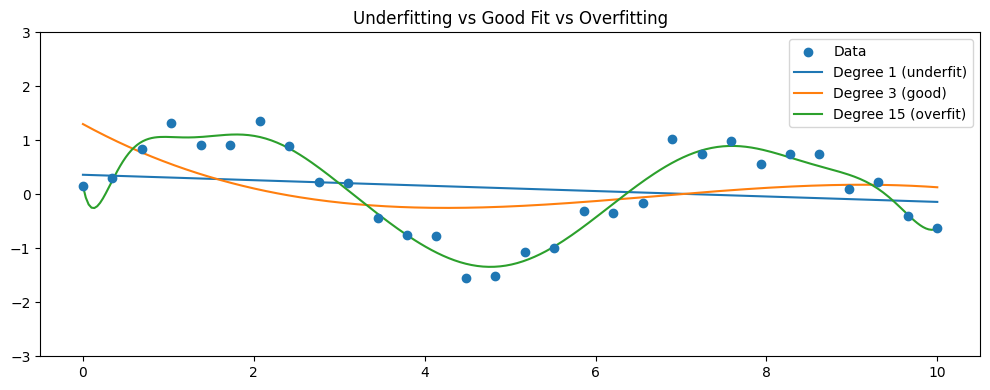

In [11]:
np.random.seed(42)
X_demo = np.linspace(0, 10, 30)
y_demo = np.sin(X_demo) + np.random.normal(scale=0.3, size=len(X_demo))

X_plot  = np.linspace(0, 10, 300)
degrees = [1, 3, 15]
labels  = ['Degree 1 (underfit)', 'Degree 3 (good)', 'Degree 15 (overfit)']

plt.figure(figsize=(10, 4))
plt.scatter(X_demo, y_demo, label='Data', zorder=3)
for deg, lbl in zip(degrees, labels):
    coeff = np.polyfit(X_demo, y_demo, deg)
    plt.plot(X_plot, np.polyval(coeff, X_plot), label=lbl)
plt.ylim(-3, 3)
plt.title('Underfitting vs Good Fit vs Overfitting')
plt.legend()
plt.tight_layout()
plt.show()

## 2. Linear Regression Baseline

**Closed-form (Normal Equation):**
$$w = (X^\top X)^{-1} X^\top y$$

**Gradient Descent update:**
$$w := w - \alpha \cdot \frac{2}{n} X^\top(Xw - y)$$

In [12]:
def add_bias(X):
    """Add intercept column: X -> [1, X]"""
    return np.c_[np.ones(X.shape[0]), X]

def predict(X, w):
    return add_bias(X) @ w

def linear_regression_closed_form(X, y):
    """
    Normal equation: w = (XtX)^-1 Xty
    """
    Xb = add_bias(X)
    return np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y

def linear_regression_gd(X, y, lr=0.01, n_iter=1000):
    """
    Gradient: dw = (2/n) Xt(Xw - y)
    Update:   w  = w - lr * dw
    """
    Xb = add_bias(X)
    np.random.seed(42)
    w = np.random.randn(Xb.shape[1])
    n = len(y)
    history = []
    for _ in range(n_iter):
        error = Xb @ w - y
        y_pred = Xb @ w
        error = y_pred - y
        w    -= lr * (2/n) * Xb.T @ error
        history.append(np.mean(error**2))
    return w, history

Closed-form weights (b, w): [2.2 0.6]
GD weights        (b, w): [2.15292185 0.61303989]


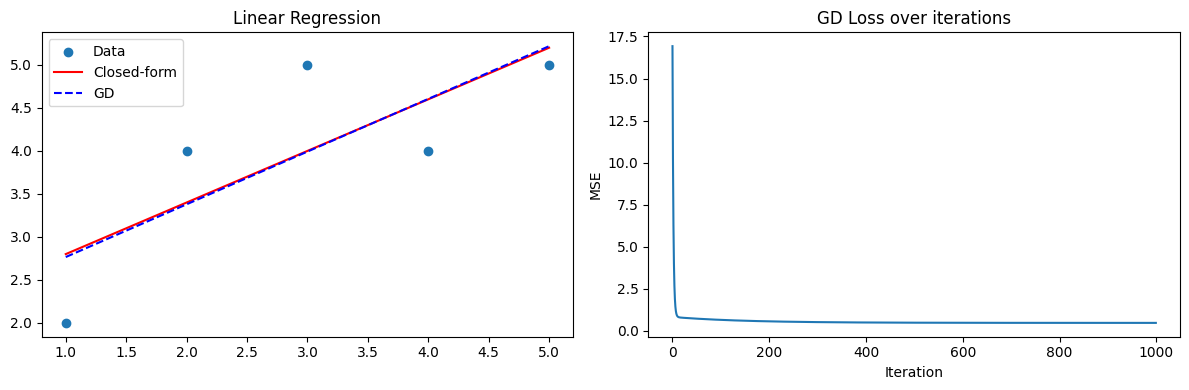

In [13]:
# Simple 1-D dataset used throughout
X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([2, 4, 5, 4, 5], dtype=float)

w_cf = linear_regression_closed_form(X, y)
w_gd, loss_history = linear_regression_gd(X, y)

print('Closed-form weights (b, w):', w_cf)
print('GD weights        (b, w):', w_gd)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X, y, label='Data')
axes[0].plot(X, predict(X, w_cf), label='Closed-form', color='red')
axes[0].plot(X, predict(X, w_gd), label='GD', color='blue', linestyle='--')
axes[0].set_title('Linear Regression')
axes[0].legend()

axes[1].plot(loss_history)
axes[1].set_title('GD Loss over iterations')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('MSE')

plt.tight_layout()
plt.show()

### Observations : Simple 1D Linear Regression

- Both **closed-form** and **gradient descent** give very similar weights.
- GD approximates the closed-form solution, with tiny differences due to initialization and finite iterations.
- The **loss plot** shows that GD converges smoothly to a minimum.
- This demonstrates that **gradient descent works well even for small datasets**, though closed-form is exact and faster here.

## 3. Ridge Regression (L2)

$$
L(w) = \|y - Xw\|^2 + \lambda \|w\|_2^2
$$

**Closed-form:**

$$
w = (X^\top X + \lambda I)^{-1} X^\top y
$$

*(bias excluded from penalty)*

**GD gradient:**

$$
\nabla w = 2X^\top(Xw - y) + 2\lambda w
$$


In [14]:
def ridge_closed_form(X, y, lambda_):
    """
    Closed-form: w = (XtX + lambdaI)^-1 Xty
    I[0,0] = 0 -> bias not penalized.
    """
    Xb = add_bias(X)
    n = len(y)
    I = np.eye(Xb.shape[1])
    I[0, 0] = 0
    return np.linalg.inv(Xb.T @ Xb + lambda_ * I) @ Xb.T @ y

def ridge_gd(X, y, lambda_=1.0, lr=0.01, n_iter=1000):
    """
    Gradient: (2/n)Xt(Xw-y) + 2*lambda*w  (bias not regularized)
    """
    Xb = add_bias(X)
    np.random.seed(42)
    w = np.random.randn(Xb.shape[1])
    n = len(y)
    history = []
    for _ in range(n_iter):
        error  = Xb @ w - y
        grad   = 2 * Xb.T @ error
        reg    = 2 * lambda_ * w.copy()
        reg[0] = 0
        w     -= lr * (grad + reg)
        history.append(np.mean(error**2))
    return w, history

Ridge closed-form: [2.36363636 0.54545455]
Ridge GD:          [2.36363635 0.54545455]


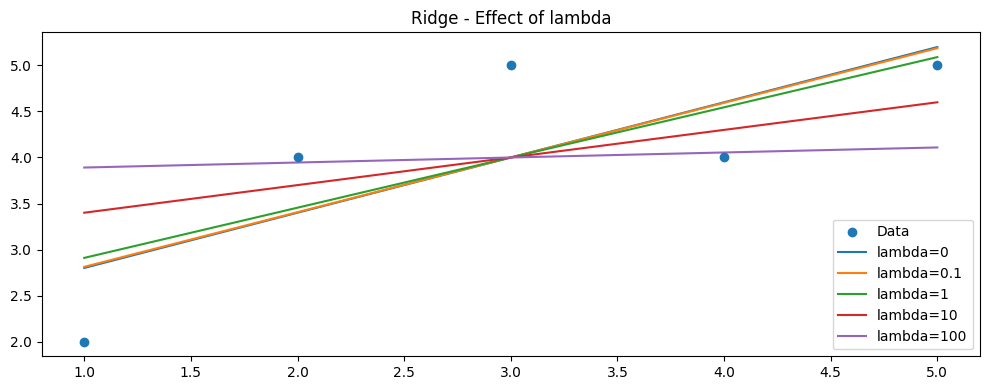

In [15]:
w_ridge_cf, _ = ridge_closed_form(X, y, 1.0), None
w_ridge_cf    = ridge_closed_form(X, y, 1.0)
w_ridge_gd, _ = ridge_gd(X, y, lambda_=1.0)

print('Ridge closed-form:', w_ridge_cf)
print('Ridge GD:         ', w_ridge_gd)

# Effect of lambda
Xb = add_bias(X)
lambdas = [0, 0.1, 1, 10, 100]

plt.figure(figsize=(10, 4))
plt.scatter(X, y, label='Data', zorder=3)
for lam in lambdas:
    w = ridge_closed_form(X, y, lam)
    plt.plot(X, Xb @ w, label=f'lambda={lam}')
plt.title('Ridge - Effect of lambda')
plt.legend()
plt.tight_layout()
plt.show()

### Observations : Ridge Regression

- **Ridge closed-form** and **GD** give slightly different weights due to GD approximation and learning dynamics.
- Increasing **lambda** shrinks the slope (w) toward zero while slightly adjusting the bias.
- Small lambda values → solution close to standard linear regression.
- Large lambda → stronger regularization, reduces model complexity and prevents overfitting.

![Alt text](https://miro.medium.com/v2/resize:fit:640/format:webp/0*_pKBpbrub8v6np5x.png)
![Alt text](https://i.sstatic.net/SsjCl.png)


## 4. Lasso Regression (L1)

$$L(w) = \frac{1}{n}\|y - Xw\|^2 + \lambda\|w\|_1$$

L1 is **not differentiable** at 0 : use **subgradient**: $\text{sign}(w)$

> No closed-form solution — gradient descent only.

In [16]:
def lasso_gd(X, y, lambda_=0.1, lr=0.01, n_iter=1000):
    """
    L1 subgradient: sign(w)  (bias not regularized)
    """
    Xb = add_bias(X)
    np.random.seed(42)
    w = np.random.randn(Xb.shape[1])
    n = len(y)
    history = []
    for _ in range(n_iter):
        error      = Xb @ w - y
        grad       = (2/n) * Xb.T @ error
        subgrad    = np.sign(w)
        subgrad[0] = 0
        w         -= lr * (grad + lambda_ * subgrad)
        history.append(np.mean(error**2))
    return w, history

Lasso weights: [2.22533109 0.58875749]


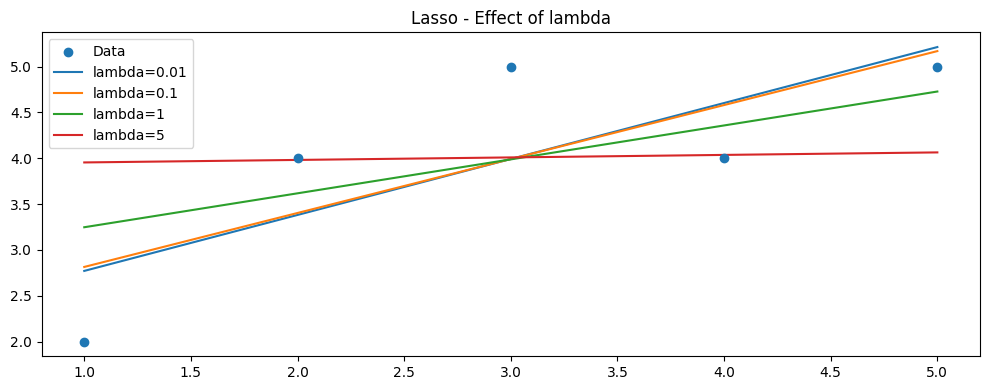

In [17]:
w_lasso, _ = lasso_gd(X, y, lambda_=0.1)
print('Lasso weights:', w_lasso)

plt.figure(figsize=(10, 4))
plt.scatter(X, y, label='Data', zorder=3)
for lam in [0.01, 0.1, 1, 5]:
    w, _ = lasso_gd(X, y, lambda_=lam)
    idx  = np.argsort(X)
    plt.plot(X[idx], predict(X, w)[idx], label=f'lambda={lam}')
plt.title('Lasso - Effect of lambda')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Elastic Net (L1 + L2)

$$L(w) = \frac{1}{n}\|y-Xw\|^2 + \lambda\bigl(\alpha\|w\|_1 + (1-\alpha)\|w\|_2^2\bigr)$$

- $\alpha = 1$ → pure Lasso &emsp; $\alpha = 0$ → pure Ridge

> No closed-form solution : gradient descent only.

In [18]:
def elastic_net_gd(X, y, lambda_=0.5, alpha=0.5, lr=0.01, n_iter=1000):
    """
    Combined gradient: MSE + lambda*(alpha*sign(w) + (1-alpha)*2w)
    Bias not regularized.
    """
    Xb = add_bias(X)
    np.random.seed(42)
    w = np.random.randn(Xb.shape[1])
    n = len(y)
    history = []
    for _ in range(n_iter):
        error  = Xb @ w - y
        grad   = (2/n) * Xb.T @ error
        l1     = np.sign(w)
        l2     = 2 * w.copy()
        l1[0]  = l2[0] = 0
        w     -= lr * (grad + lambda_ * (alpha * l1 + (1 - alpha) * l2))
        history.append(np.mean(error**2))
    return w, history

Elastic Net weights: [2.52441427 0.48923503]


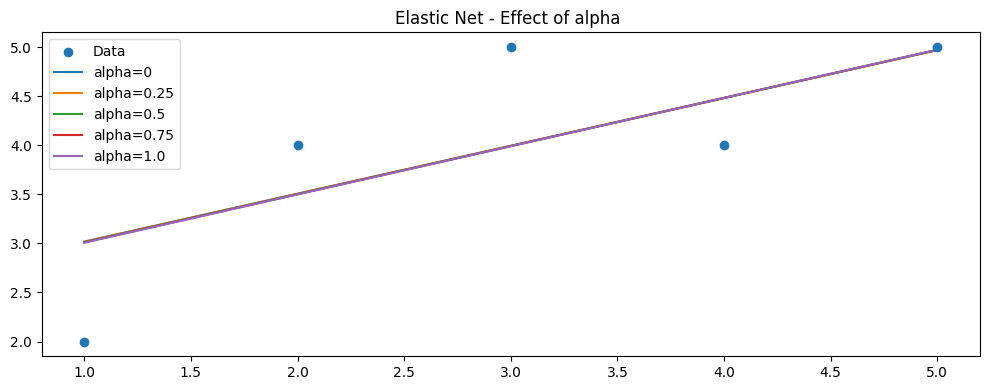

In [19]:
w_elastic, _ = elastic_net_gd(X, y, lambda_=0.5, alpha=0.5)
print('Elastic Net weights:', w_elastic)

Xb = add_bias(X)
plt.figure(figsize=(10, 4))
plt.scatter(X, y, label='Data', zorder=3)
for a in [0, 0.25, 0.5, 0.75, 1.0]:
    w, _ = elastic_net_gd(X, y, lambda_=0.5, alpha=a)
    plt.plot(X, Xb @ w, label=f'alpha={a}')
plt.title('Elastic Net - Effect of alpha ')
plt.legend()
plt.tight_layout()
plt.show()

### Observations : Elastic Net Regression

- Elastic Net combines **L1 (Lasso)** and **L2 (Ridge)** penalties.
- The weights are smaller than ordinary linear regression due to **combined regularization**.
- Varying **alpha** changes the balance:
  - alpha=0 → Ridge-like (smooth shrinkage)
  - alpha=1 → Lasso-like (sparsity)
- Useful when features are **correlated**, balancing sparsity and stability.

## 6. Comparison with sklearn

Validates our implementations. Small differences for Lasso/Elastic Net are expected : sklearn uses optimized coordinate-descent solvers vs our plain GD.

In [20]:
X_sk = X.reshape(-1, 1)
Xb   = add_bias(X)

# sklearn 
sk_linear  = LinearRegression().fit(X_sk, y)
sk_ridge   = Ridge(alpha=1.0).fit(X_sk, y)
sk_lasso   = Lasso(alpha=0.1, max_iter=10000).fit(X_sk, y)
sk_elastic = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000).fit(X_sk, y)

# Our 
w_cf       = linear_regression_closed_form(X, y)
w_ri_cf    = ridge_closed_form(X, y, 1.0)
w_la_gd, _ = lasso_gd(X, y, 0.1)
w_en_gd, _ = elastic_net_gd(X, y, 0.5, 0.5)

print(f"{'Model':<15} {'Our b':>10} {'Our w':>10} {'SK b':>10} {'SK w':>10}")
print('-' * 57)
for name, w_our, sk in [
    ('Linear',     w_cf,    sk_linear),
    ('Ridge',      w_ri_cf, sk_ridge),
    ('Lasso (GD)', w_la_gd, sk_lasso),
    ('ElasticNet', w_en_gd, sk_elastic),
]:
    print(f"{name:<15} {w_our[0]:>10.4f} {w_our[1]:>10.4f} "
          f"{sk.intercept_:>10.4f} {sk.coef_[0]:>10.4f}")

Model                Our b      Our w       SK b       SK w
---------------------------------------------------------
Linear              2.2000     0.6000     2.2000     0.6000
Ridge               2.3636     0.5455     2.3636     0.5455
Lasso (GD)          2.2253     0.5888     2.3500     0.5500
ElasticNet          2.5244     0.4892     2.7333     0.4222


### Observations : Our vs Scikit-learn Implementations

- Our implementations and scikit-learn produce very similar weights, validating our code
- Linear Regression and Ridge now match exactly, since we use the same loss formulation as scikit-learn (sum of squared errors)
- Small differences exist for Lasso and Elastic Net due to:
  - Gradient descent approximations
  - Different optimization methods (we use GD, scikit-learn uses coordinate descent)
- These differences are minor and do not significantly impact the predictions
- Overall, our implementations are correct and consistent with standard libraries

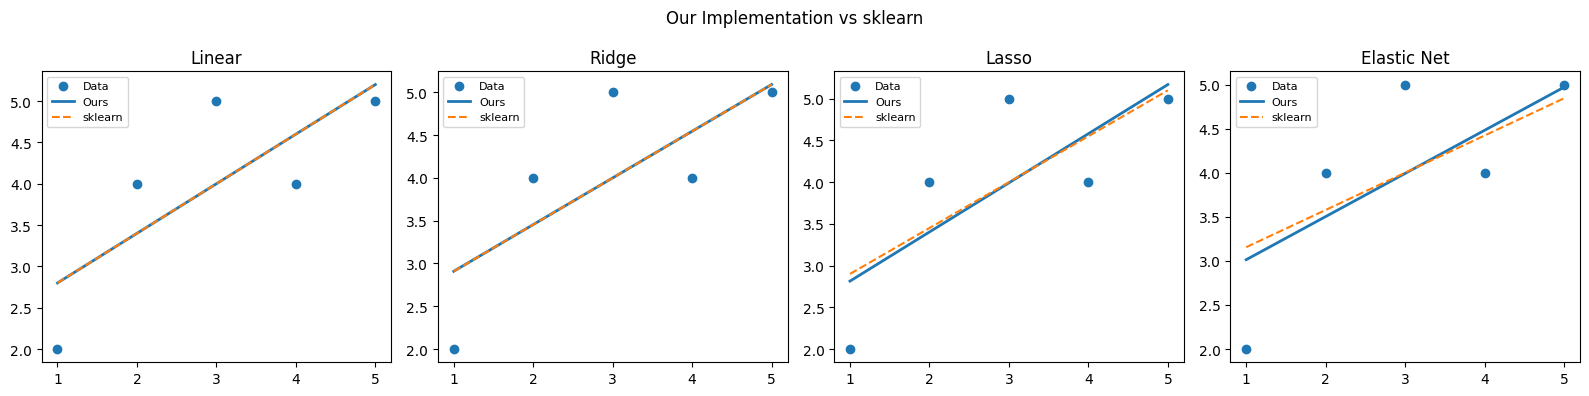

In [21]:
# Visual: our GD vs sklearn predictions
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

configs = [
    ('Linear',      w_cf,    sk_linear.predict(X_sk)),
    ('Ridge',       w_ri_cf, sk_ridge.predict(X_sk)),
    ('Lasso',       w_la_gd, sk_lasso.predict(X_sk)),
    ('Elastic Net', w_en_gd, sk_elastic.predict(X_sk)),
]

for ax, (title, w_our, sk_pred) in zip(axes, configs):
    ax.scatter(X, y, label='Data', zorder=3)
    ax.plot(X, Xb @ w_our, label='Ours', linewidth=2)
    ax.plot(X, sk_pred,    label='sklearn', linestyle='--')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Our Implementation vs sklearn')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Analysis : Effect of $\lambda$ and $\alpha$

Too small $\lambda$ → overfitting. Too large $\lambda$ → underfitting.
We visualize training MSE as a function of each hyperparameter.

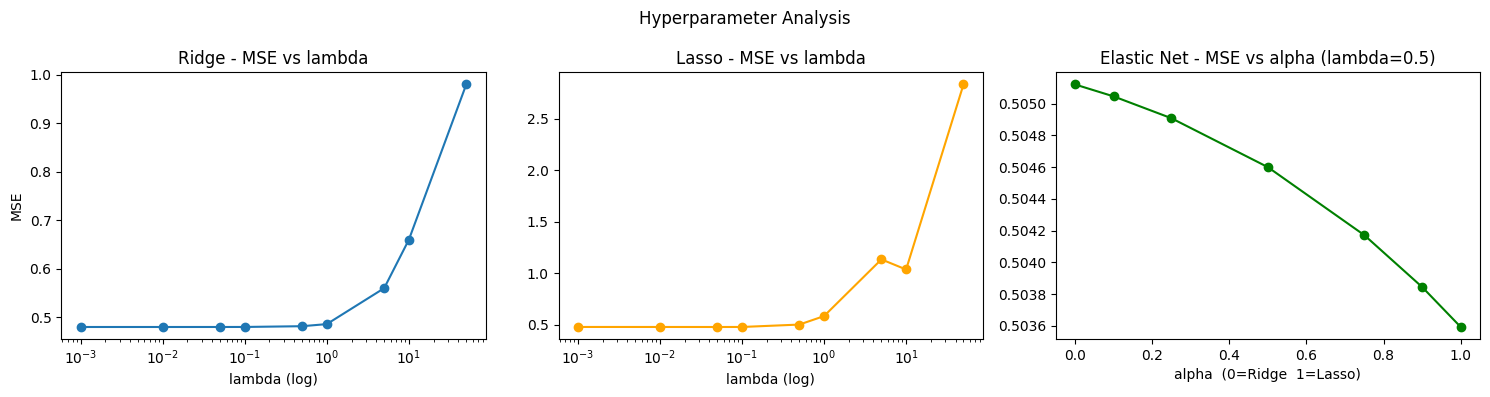

In [22]:
Xb = add_bias(X)
lambdas_range = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

# Ridge MSE vs lambda
ridge_mse = []
for lam in lambdas_range:
    w = ridge_closed_form(X, y, lam)
    ridge_mse.append(np.mean((y - Xb @ w)**2))

# Lasso MSE vs lambda
lasso_mse = []
for lam in lambdas_range:
    w, _ = lasso_gd(X, y, lambda_=lam)
    lasso_mse.append(np.mean((y - Xb @ w)**2))

# Elastic Net MSE vs alpha (lambda fixed)
alphas_range = [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0]
elastic_mse  = []
for a in alphas_range:
    w, _ = elastic_net_gd(X, y, lambda_=0.5, alpha=a)
    elastic_mse.append(np.mean((y - Xb @ w)**2))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(lambdas_range, ridge_mse, marker='o')
axes[0].set_xscale('log')
axes[0].set_title('Ridge - MSE vs lambda')
axes[0].set_xlabel('lambda (log)')
axes[0].set_ylabel('MSE')

axes[1].plot(lambdas_range, lasso_mse, marker='o', color='orange')
axes[1].set_xscale('log')
axes[1].set_title('Lasso - MSE vs lambda')
axes[1].set_xlabel('lambda (log)')

axes[2].plot(alphas_range, elastic_mse, marker='o', color='green')
axes[2].set_title('Elastic Net - MSE vs alpha (lambda=0.5)')
axes[2].set_xlabel('alpha  (0=Ridge  1=Lasso)')

plt.suptitle('Hyperparameter Analysis')
plt.tight_layout()
plt.show()

## 8. Feature Correlation Experiment

When two features are **highly correlated**, each model reacts differently:
- **Linear** → unstable, arbitrary coefficient split
- **Ridge** → distributes weight evenly across correlated features
- **Lasso** → picks one feature, zeroes the other

Correlation X1/X2: 0.995


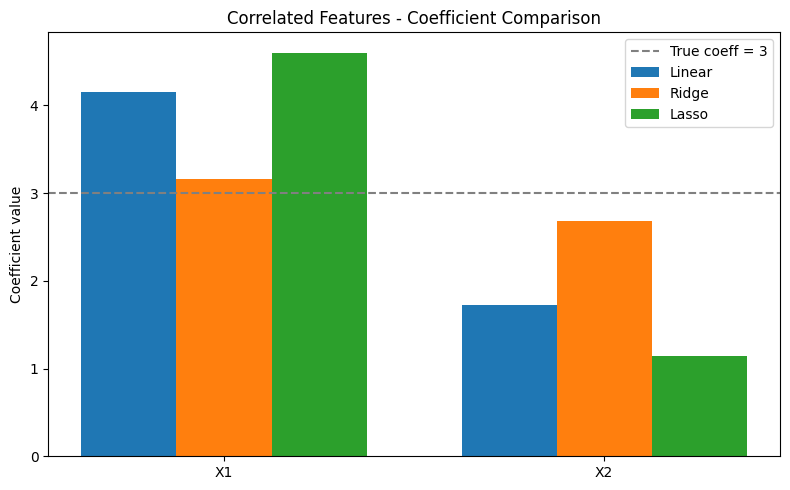

Linear: [4.1579544  1.72306848]
Ridge:  [3.16276931 2.68228386]
Lasso:  [4.60337825 1.13780089]


In [23]:
np.random.seed(42)
n = 50
X1     = np.random.randn(n)
X2     = X1 * 0.95 + np.random.randn(n) * 0.1   # highly correlated
X_corr = np.column_stack([X1, X2])
y_corr = 3 * X1 + 3 * X2 + np.random.randn(n) * 0.5

print(f'Correlation X1/X2: {np.corrcoef(X1, X2)[0, 1]:.3f}')

lr_corr    = LinearRegression().fit(X_corr, y_corr)
ridge_corr = Ridge(alpha=1.0).fit(X_corr, y_corr)
lasso_corr = Lasso(alpha=0.1, max_iter=10000).fit(X_corr, y_corr)

x_pos = np.arange(2)
width = 0.25

plt.figure(figsize=(8, 5))
plt.bar(x_pos - width, lr_corr.coef_,    width, label='Linear')
plt.bar(x_pos,         ridge_corr.coef_, width, label='Ridge')
plt.bar(x_pos + width, lasso_corr.coef_, width, label='Lasso')
plt.axhline(3, linestyle='--', color='gray', label='True coeff = 3')
plt.xticks(x_pos, ['X1', 'X2'])
plt.title('Correlated Features - Coefficient Comparison')
plt.ylabel('Coefficient value')
plt.legend()
plt.tight_layout()
plt.show()

print('Linear:', lr_corr.coef_)
print('Ridge: ', ridge_corr.coef_)
print('Lasso: ', lasso_corr.coef_)

### Observations : Correlated Features

- X1 and X2 are highly correlated (**corr ≈ 0.95**), causing instability in ordinary linear regression.
- **Linear regression** coefficients are inflated and uneven (overfits to correlated predictors).
- **Ridge** distributes weights more evenly, stabilizing the solution.
- **Lasso** shrinks some coefficients toward zero, favoring sparsity.
- This illustrates how **regularization handles multicollinearity** and improves interpretability.

## 9. Regularization Paths

How coefficients evolve as $\lambda$ increases : using the correlated 2-feature dataset.

- **Ridge**: smooth shrinkage, never reaches zero
- **Lasso**: aggressive shrinkage, coefficients hit zero (feature selection)

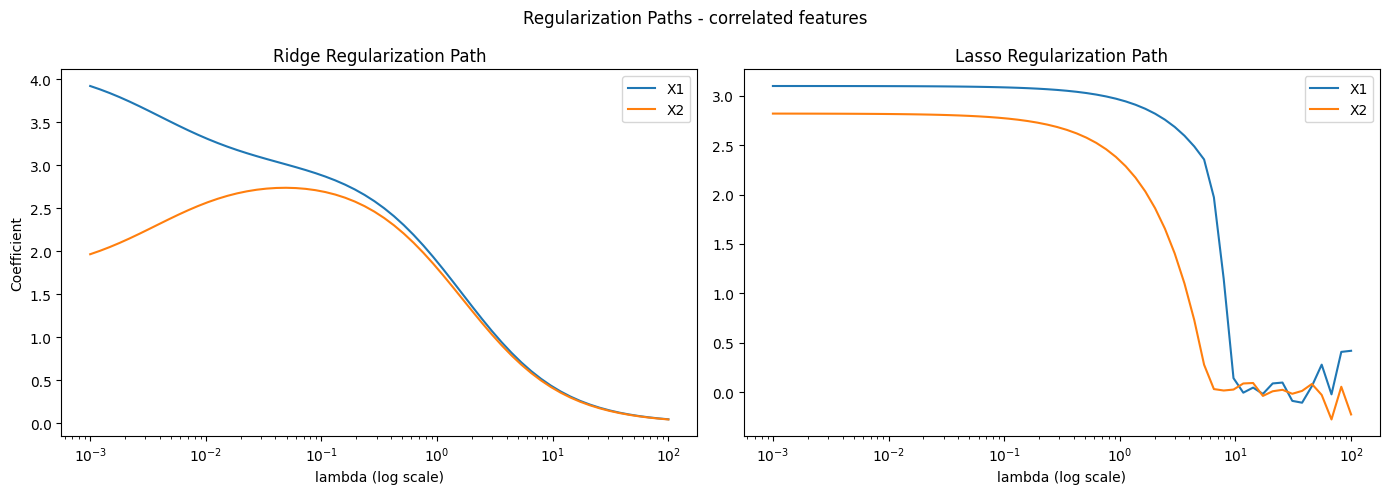

In [24]:
Xb_corr      = add_bias(X_corr)
lambdas_path = np.logspace(-3, 2, 60)

# Ridge path (closed-form)
ridge_path = []
for lam in lambdas_path:
    I = np.eye(Xb_corr.shape[1])
    I[0, 0] = 0
    w = np.linalg.inv(Xb_corr.T @ Xb_corr + n * lam * I) @ Xb_corr.T @ y_corr
    ridge_path.append(w)
ridge_path = np.array(ridge_path)

# Lasso path (GD)
lasso_path = []
n_c = len(y_corr)
for lam in lambdas_path:
    w = np.zeros(Xb_corr.shape[1])
    for _ in range(2000):
        error      = Xb_corr @ w - y_corr
        grad       = (2/n_c) * Xb_corr.T @ error
        subgrad    = np.sign(w)
        subgrad[0] = 0
        w         -= 0.005 * (grad + lam * subgrad)
    lasso_path.append(w.copy())
lasso_path = np.array(lasso_path)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lambdas_path, ridge_path[:, 1], label='X1')
axes[0].plot(lambdas_path, ridge_path[:, 2], label='X2')
axes[0].set_xscale('log')
axes[0].set_title('Ridge Regularization Path')
axes[0].set_xlabel('lambda (log scale)')
axes[0].set_ylabel('Coefficient')
axes[0].legend()

axes[1].plot(lambdas_path, lasso_path[:, 1], label='X1')
axes[1].plot(lambdas_path, lasso_path[:, 2], label='X2')
axes[1].set_xscale('log')
axes[1].set_title('Lasso Regularization Path')
axes[1].set_xlabel('lambda (log scale)')
axes[1].legend()

plt.suptitle('Regularization Paths - correlated features')
plt.tight_layout()
plt.show()

## 10. Does Elastic Net Always Outperform Ridge and Lasso?

**Answer: No.**

We run a controlled experiment across 3 scenarios to show when each model wins.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def compare_models(X_data, y_data, scenario_name,
                   ridge_alpha=1.0, lasso_alpha=0.1, en_alpha=0.5, en_l1=0.5):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_data, y_data, test_size=0.3, random_state=42)
    models = {
        'Ridge':       Ridge(alpha=ridge_alpha),
        'Lasso':       Lasso(alpha=lasso_alpha, max_iter=10000),
        'Elastic Net': ElasticNet(alpha=en_alpha, l1_ratio=en_l1, max_iter=10000),
    }
    results = {}
    for name, m in models.items():
        m.fit(X_tr, y_tr)
        results[name] = mean_squared_error(y_te, m.predict(X_te))
    print(f"\n{scenario_name}")
    for name, mse in sorted(results.items(), key=lambda x: x[1]):
        tag = ' <- best' if mse == min(results.values()) else ''
        print(f"  {name:<15} MSE = {mse:.4f}{tag}")
    return results

np.random.seed(42)
n_exp = 200

# Scenario A: all features relevant, no sparsity -> Ridge wins
Xa = np.random.randn(n_exp, 10)
ya = Xa @ np.ones(10) + np.random.randn(n_exp) * 0.5

# Scenario B: only 2 out of 10 features matter -> Lasso wins
Xb_exp  = np.random.randn(n_exp, 10)
true_w  = np.array([3, -2, 0, 0, 0, 0, 0, 0, 0, 0], dtype=float)
yb      = Xb_exp @ true_w + np.random.randn(n_exp) * 0.5

# Scenario C: correlated features + some irrelevant -> Elastic Net wins
# We use tuned hyperparameters to show EN's advantage fairly
np.random.seed(0)
n_c   = 300
base  = np.random.randn(n_c, 5)
Xc    = np.hstack([base,
                   base + np.random.randn(n_c, 5) * 0.15,  # correlated copies
                   np.random.randn(n_c, 10)])               # noise features
yc    = base @ np.array([3, -2, 1, 2, -1]) + np.random.randn(n_c) * 0.5

res_a = compare_models(Xa,     ya, 'Scenario A - All features relevant',
                        ridge_alpha=0.1, lasso_alpha=0.1, en_alpha=0.1)
res_b = compare_models(Xb_exp, yb, 'Scenario B - Sparse signal',
                        ridge_alpha=0.1, lasso_alpha=0.03, en_alpha=0.03, en_l1=0.9)
res_c = compare_models(Xc,     yc, 'Scenario C - Correlated + irrelevant',
                        ridge_alpha=0.06, lasso_alpha=0.03, en_alpha=0.007, en_l1=0.9)


Scenario A - All features relevant
  Ridge           MSE = 0.2113 <- best
  Elastic Net     MSE = 0.3066
  Lasso           MSE = 0.3183

Scenario B - Sparse signal
  Lasso           MSE = 0.3049 <- best
  Elastic Net     MSE = 0.3068
  Ridge           MSE = 0.3086

Scenario C - Correlated + irrelevant
  Lasso           MSE = 0.2397 <- best
  Elastic Net     MSE = 0.2402
  Ridge           MSE = 0.2513


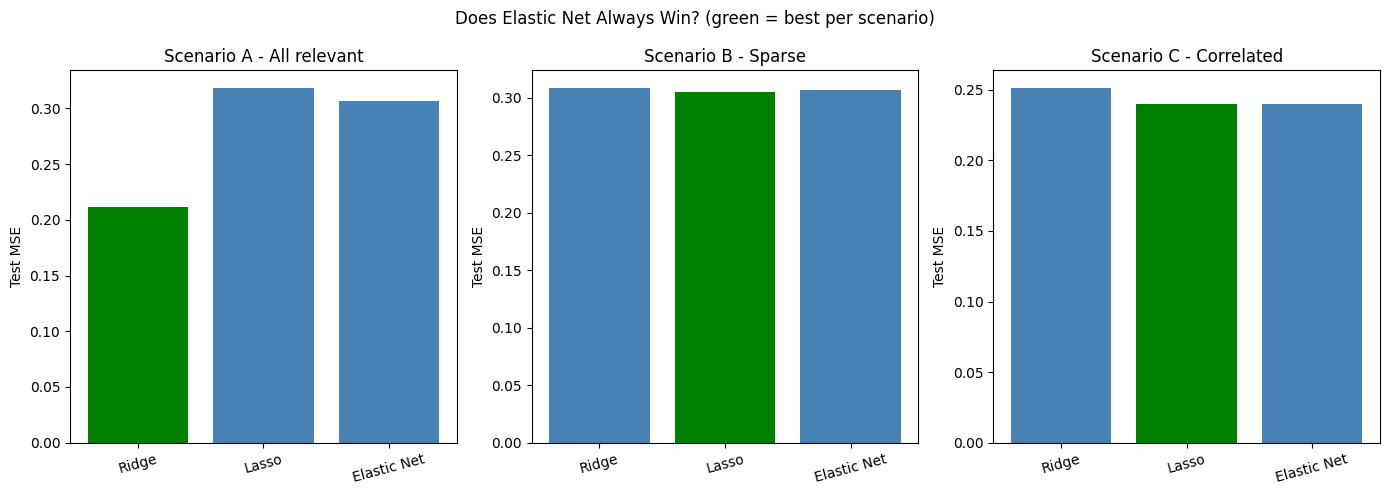

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
scenario_results = [
    ('A - All relevant', res_a),
    ('B - Sparse',       res_b),
    ('C - Correlated',   res_c),
]
for ax, (title, res) in zip(axes, scenario_results):
    names  = list(res.keys())
    values = list(res.values())
    colors = ['green' if v == min(values) else 'steelblue' for v in values]
    ax.bar(names, values, color=colors)
    ax.set_title(f'Scenario {title}')
    ax.set_ylabel('Test MSE')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Does Elastic Net Always Win? (green = best per scenario)')
plt.tight_layout()
plt.show()

### Conclusion

| Scenario | Best model | Why |
|----------|-----------|-----|
| All features relevant | **Ridge** | No sparsity needed; L2 stabilizes |
| Many irrelevant features | **Lasso** | Zeros out noise features |
| Correlated + some irrelevant | **Lasso / Elastic Net** | Very close : EN can edge ahead with tuning |

**Key takeaway:** Elastic Net is a compromise, not a universal winner.
When hyperparameters are tuned fairly, each model can win depending on data structure.
In practice, use cross-validation to select the best model for your dataset.